## Ensemble Methods: Bagging, Boosting, and Stacking

### Bagging (Bootstrap Aggregating)
- Trains multiple **identical models** on different bootstrap samples  
- Models are trained **independently and in parallel**
- Final prediction is obtained by **averaging** (regression) or **majority voting** (classification)
- Mainly reduces **variance**
- Works well with **unstable models** (e.g., decision trees)
- Example: **Random Forest**

---

### Boosting
- Models are trained **sequentially**
- Each new model focuses on **errors made by previous models**
- Final prediction is a **weighted sum** of all models
- Mainly reduces **bias**
- Can be sensitive to noise
- Examples: **AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost**

---

### Stacking
- Combines **different types of models**
- Base models generate **predictions used as features**
- A **meta-model** learns how to combine these predictions
- Uses **out-of-fold predictions** to avoid data leakage
- Often achieves high performance but is **more complex**
- Common meta-models: **Linear / Logistic Regression**


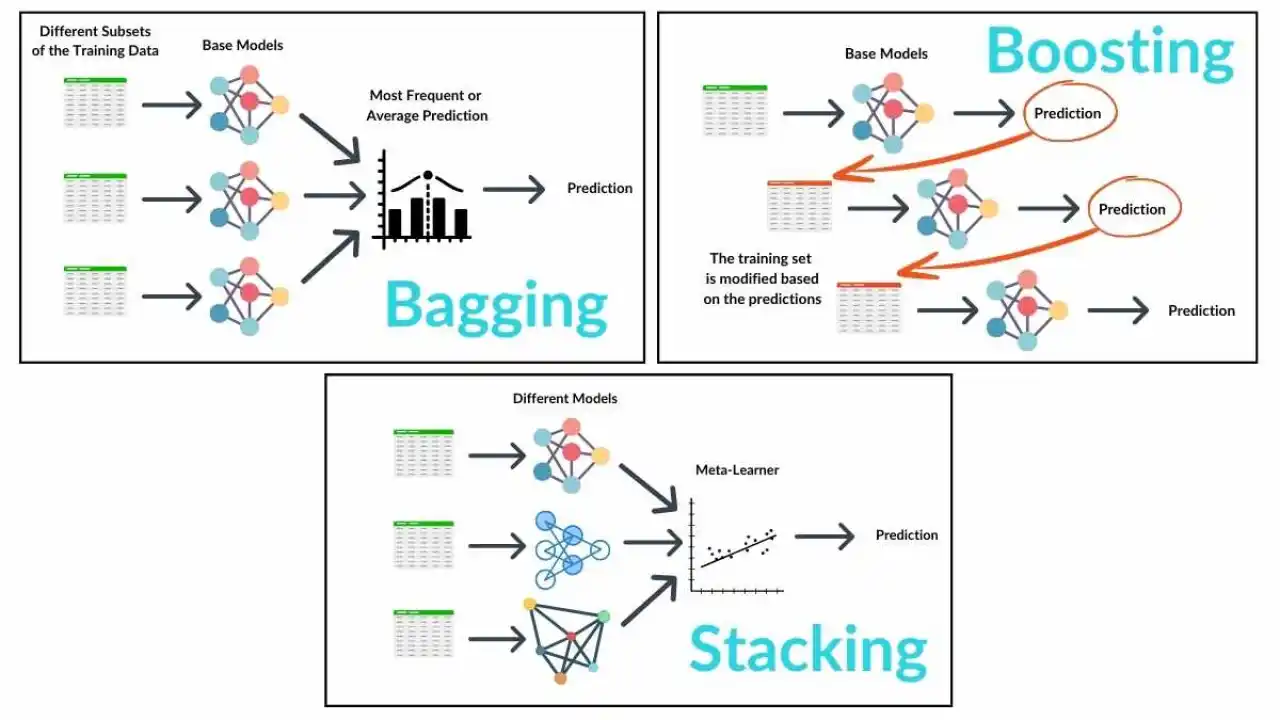

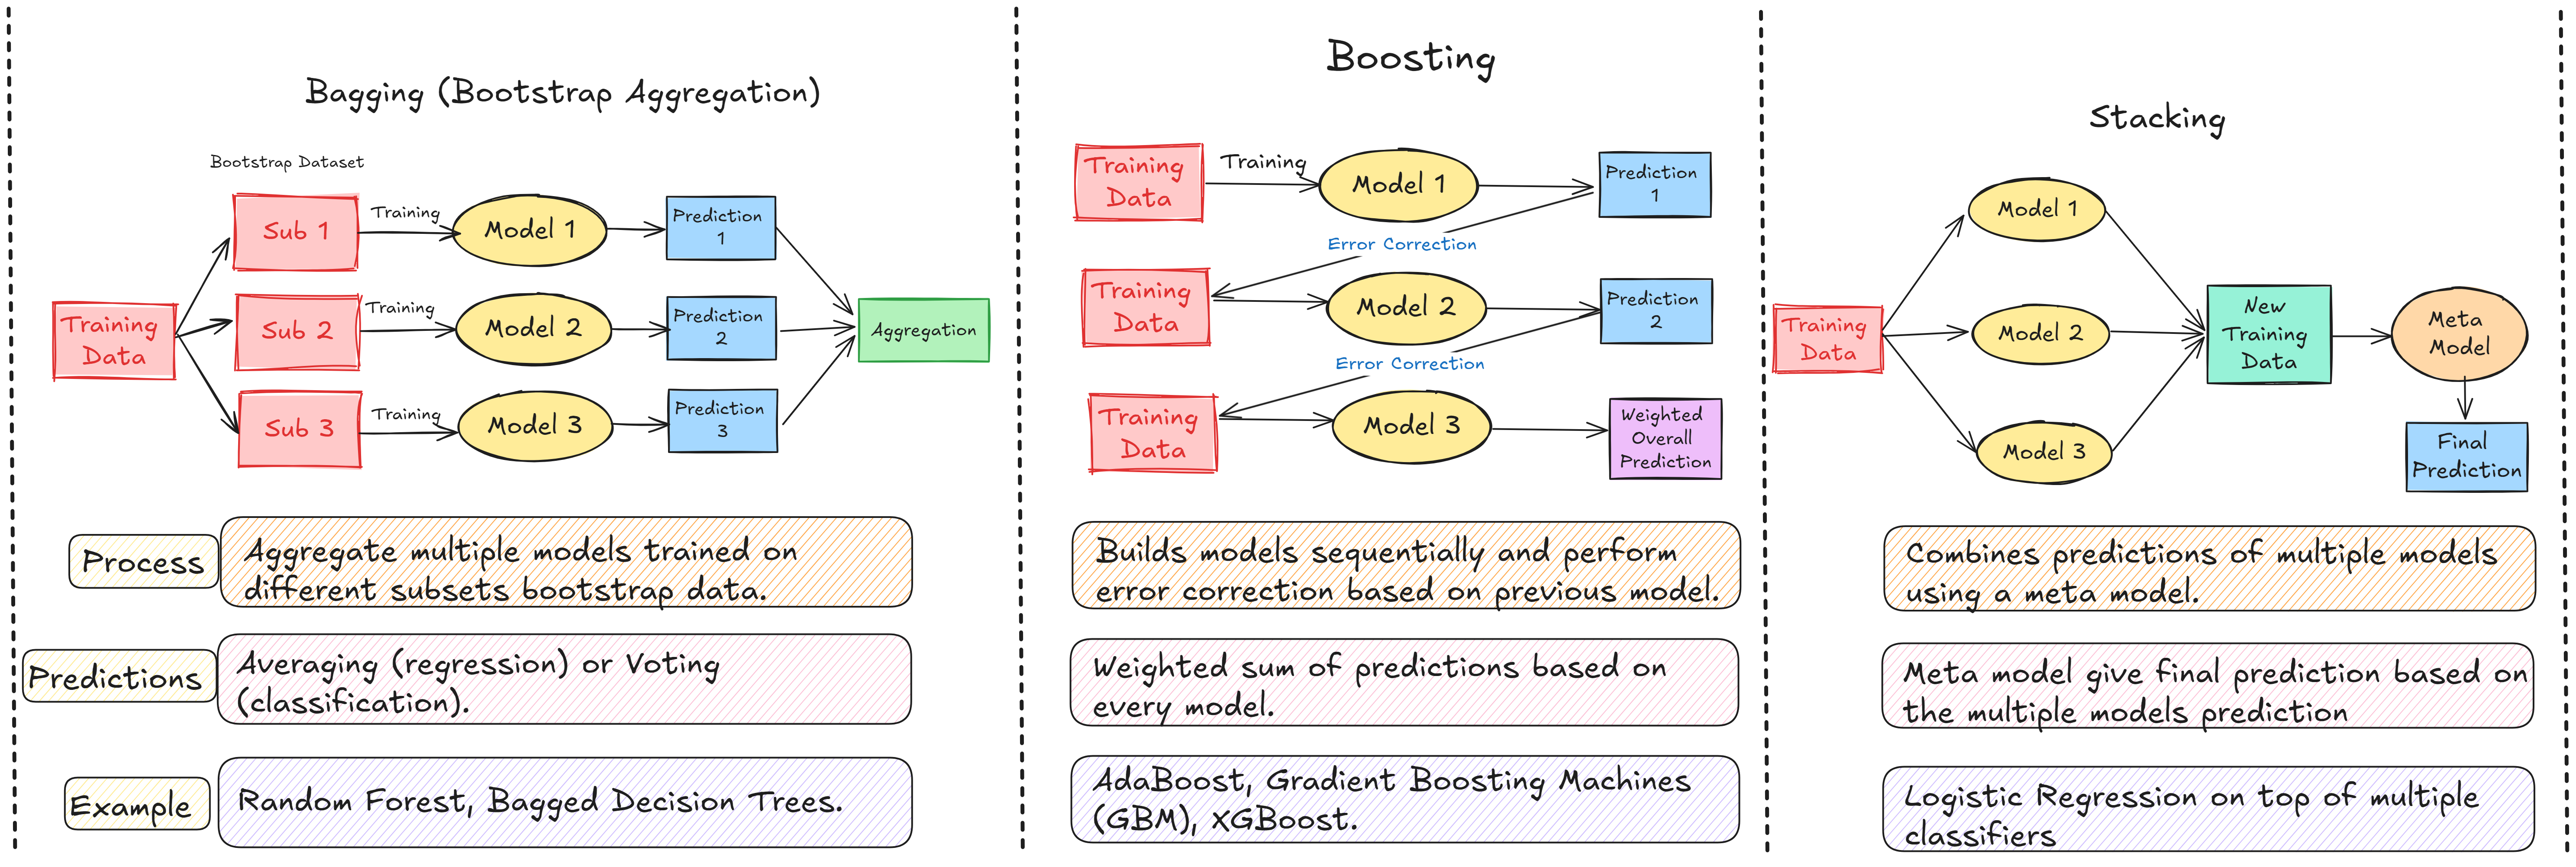

# Staking

https://www.geeksforgeeks.org/machine-learning/stacking-in-machine-learning/

Stacking architecture is like a team of models working together in two layers to improve prediction accuracy

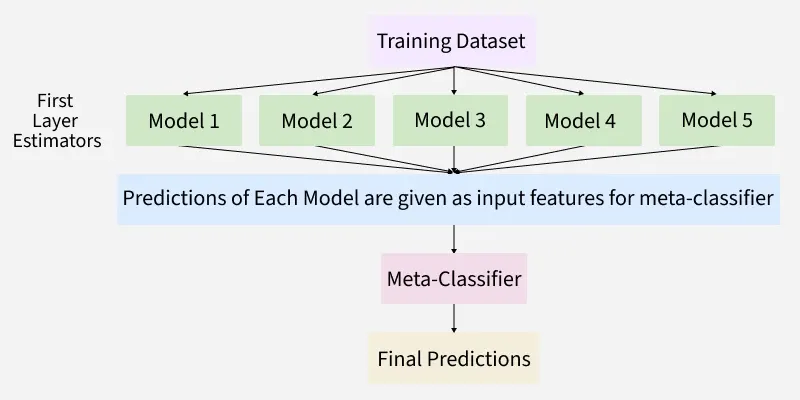

In [ ]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import accuracy_score


In [ ]:
#X, y = load_iris(return_X_y=True)
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)




In [ ]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)  
y_pred_rf = model_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)  
print('Accuracy Score of KNeighbors Classifier:', acc_rf * 100)

Accuracy Score of KNeighbors Classifier: 92.10526315789474


In [ ]:
model_NaiveBayes = GaussianNB()
model_NaiveBayes.fit(X_train, y_train)
y_pred_nb = model_NaiveBayes.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
print('Accuracy of Naive Bayes Classifier:', acc_nb * 100)

Accuracy of Naive Bayes Classifier: 92.10526315789474


In [ ]:
y_test

array([0, 1, 1, 1, 0, 1, 2, 2, 2, 2, 2, 2, 1, 1, 0, 0, 0, 1, 0, 1, 2, 1,
       2, 1, 2, 1, 0, 2, 0, 1, 2, 2, 0, 0, 0, 0, 2, 1])

In [ ]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
    ('nb', make_pipeline(GaussianNB()))
]
clf = StackingClassifier(
    estimators=estimators, final_estimator=LogisticRegression()
)


clf.fit(X_train, y_train).score(X_test, y_test)

0.9210526315789473